# BCAE with parameter-reduced EVT

This notebook contains the pipeline-dataset experiment, computational-efficiency evaluation, TEP cross-dataset validation, and EVT sensitivity analysis. Saved outputs are retained for reviewer inspection. The underlying industrial data cannot be redistributed; rerunning the data-dependent cells requires an authorized preprocessing module configured as described in README.md.

In [1]:
import math
import random

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from model import FlexibleConv1dAutoencoder, contrastive_loss
from evt import estimate_q_from_hill_plot_grimshaw, SPOT
from contamination import build_drift_contaminated_dataset

In [3]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
from data_adapter import ld_dataset, tep_dataset

# Configure BCAE_DATASET_MODULE_DIR as described in README.md.

In [5]:
def data_set(
    batch_size,
    known_index,
    contamination_ratio=0.0,
    contamination_type=None,
    seed=0,
):
    """
    Build training and test data loaders.

    contamination_ratio=0.0 uses the clean training set.
    A positive ratio injects sensor-drift or working-condition contamination.
    """

    x_train, y_train, x_test, y_test, _, _ = ld_dataset(
        construct_long_short=False,
        imb=0,
        known_index=known_index
    )


    if contamination_ratio > 0:
        if contamination_type is None:
            contamination_type = "mixed"

        x_train, y_train, x_test, y_test, info = build_drift_contaminated_dataset(
            x_train=x_train,
            y_train=y_train,
            x_test=x_test,
            y_test=y_test,
            contamination_ratio=contamination_ratio,
            contamination_type=contamination_type,
            seed=seed,
            channel_ratio=0.5,
            scale_std=0.15,
            bias_level=0.2,
            trend_level=0.2,
            noise_level=0.05,
            return_info=True,
        )

        print(
            f"Contamination type: {contamination_type}, "
            f"ratio: {contamination_ratio:.0%}, "
            f"contaminated samples: {info['n_contaminated']}"
        )

    # Conv1d expects tensors in (N, C, L) format.
    tensor_x_train = torch.as_tensor(
        x_train.transpose((0, 2, 1)),
        dtype=torch.float32
    )

    tensor_x_test = torch.as_tensor(
        x_test.transpose((0, 2, 1)),
        dtype=torch.float32
    )

    tensor_y_test = torch.as_tensor(
        y_test,
        dtype=torch.float32
    )

    # Training labels are intentionally excluded from model optimization.
    train_loader = Data.DataLoader(
        dataset=tensor_x_train,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    test_loader = Data.DataLoader(
        dataset=Data.TensorDataset(tensor_x_test, tensor_y_test),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader

Dataset Normal-1  Normal-2  Adjustment  Ice block   Leak
Training set &1794 &2520 &1041 &1854 &0
Training set &769 &1081 &447 &795 &2855
All &2563 &3601 &1488 &2650 &2855
Testing
max_train_errors=0.0480


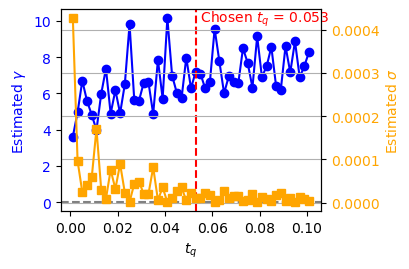

t_best=0.053000000000000005,anomaly_ratio=0.02
gamma=7.209,sigma=1.024e-05
Extreme Value threshold. Acc:0.9741, P:0.9608, R:0.9863, F1:0.9734, FDR:0.9863, FAR:0.0372, AUC:0.9975
Dataset Normal-1  Normal-2  Adjustment  Ice block   Leak
Training set &1794 &2520 &1041 &1854 &0
Training set &769 &1081 &447 &795 &2855
All &2563 &3601 &1488 &2650 &2855
Testing
max_train_errors=0.0257


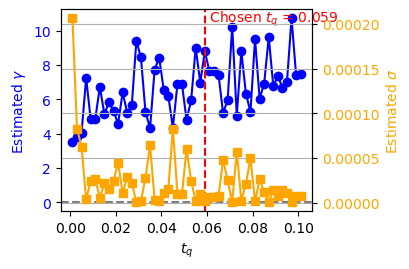

t_best=0.059000000000000004,anomaly_ratio=0.02
gamma=8.8,sigma=1.889e-06
Extreme Value threshold. Acc:0.9622, P:0.9839, R:0.9540, F1:0.9687, FDR:0.9540, FAR:0.0248, AUC:0.9966
Dataset Normal-1  Normal-2  Adjustment  Ice block   Leak
Training set &1794 &2520 &1041 &1854 &0
Training set &769 &1081 &447 &795 &2855
All &2563 &3601 &1488 &2650 &2855
Testing
max_train_errors=0.0385


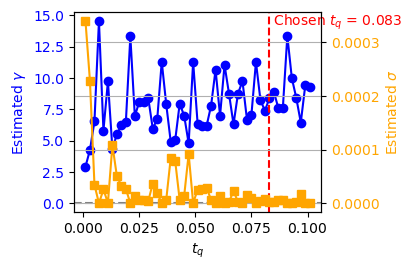

t_best=0.083,anomaly_ratio=0.03
gamma=8.378,sigma=3.356e-06
Extreme Value threshold. Acc:0.9534, P:0.9616, R:0.9543, F1:0.9579, FDR:0.9543, FAR:0.0476, AUC:0.9925
Dataset Normal-1  Normal-2  Adjustment  Ice block   Leak
Training set &1794 &2520 &1041 &1854 &0
Training set &769 &1081 &447 &795 &2855
All &2563 &3601 &1488 &2650 &2855
Testing
max_train_errors=0.0350


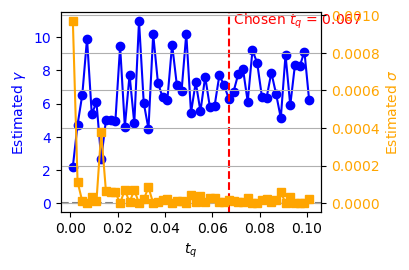

t_best=0.067,anomaly_ratio=0.03
gamma=6.296,sigma=2.014e-05
Extreme Value threshold. Acc:0.9571, P:0.9676, R:0.9702, F1:0.9689, FDR:0.9702, FAR:0.0719, AUC:0.9927


In [6]:
group_to_index = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
known_classes = [[0, 1, 2, 3], [0, 1, 2], [0, 1, 3], [0, 1]]
unknown_classes = [[4], [3, 4], [2, 4], [2, 3, 4]]

for dataset_name in ['A', 'B', 'C', 'D']:
    dataset_index = group_to_index[dataset_name]
    alpha = beta = 1

    set_seed(42)
    conv_channels = [32, 16, 64]
    use_batchnorm = True
    latent_dim = 8
    kernel_size = 4
    activation = "leakyrelu"
    lr = 0.0001
    epochs = 80
    lamb = 0.05
    tau = 1
    batch_size = 64

    known_index = known_classes[dataset_index]
    unknown_index = unknown_classes[dataset_index]
    train_loader, test_loader = data_set(batch_size, known_index)

    # 2. Build the model.
    model = FlexibleConv1dAutoencoder(
        in_channels=14,
        conv_channels=conv_channels,
        kernel_size=kernel_size,
        latent_dim=latent_dim,
        activation=activation,
        use_batchnorm=use_batchnorm
    ).to(device)


    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # 3. Train the model.
    model.train()
    for epoch in range(epochs):
        for batch in train_loader:
            x = batch.to(device)
            out = model(x)
            loss = criterion(out, x) + lamb * contrastive_loss(
                x, out, tau, alpha, beta
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


    # 4. Compute reconstruction errors and evaluation metrics.
    print("Testing")
    model.eval()

    train_errors = []
    with torch.no_grad():
        for batch in train_loader:
            x = batch.to(device)
            out = model(x)
            error = torch.mean((x - out) ** 2, dim=[1, 2])
            train_errors.extend(error.cpu().numpy())

    train_errors = np.asarray(train_errors)

    all_errors = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            x, y = batch[0].to(device), batch[1].to(device)
            out = model(x)
            error = torch.mean((x - out) ** 2, dim=[1, 2])
            all_errors.extend(error.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    all_labels = np.asarray(all_labels)
    all_errors = np.asarray(all_errors)
    leak_label = np.isin(all_labels, unknown_index).astype(int)
    auc = roc_auc_score(leak_label, all_errors)

    print(f'max_train_errors={train_errors.max():.4f}')
    t_best = estimate_q_from_hill_plot_grimshaw(
        train_errors, SPOT(), (0.001, 0.1), 0.002
    )
    anomaly_ratio = math.ceil(t_best / 3 * 100) / 100
    print(f't_best={t_best},anomaly_ratio={anomaly_ratio}')
    spot = SPOT()
    threshold, t, x0, t1, gamma, sigma = spot._pot(
        train_errors, anomaly_ratio, initial_thr_ratio=t_best
    )

    predictions = (all_errors >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        leak_label, predictions, average='binary'
    )
    acc = accuracy_score(leak_label, predictions)
    tn, fp, fn, tp = confusion_matrix(leak_label, predictions).ravel()
    fdr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    print(
        f'Extreme Value threshold. '
        f'Acc:{acc:.4f}, '
        f'P:{p:.4f}, '
        f'R:{r:.4f}, '
        f'F1:{f1:.4f}, '
        f'FDR:{fdr:.4f}, '
        f'FAR:{far:.4f}, '
        f'AUC:{auc:.4f}'
    )

## Computational efficiency

The following cell measures parameter count, training time, peak GPU memory, and per-sample inference latency for the most recently trained pipeline-dataset model. Runtime measurements can vary slightly across executions; the final line records the rounded reference-run values reported in the paper.

In [7]:
import time

from computational_complexity import count_model_parameters, measure_inference_latency

# Parameter count.
param_info = count_model_parameters(model)

print("========== Model Complexity ==========")
print(f"Model parameters: {param_info}")

# Training time and peak allocated GPU memory.
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()

start = time.perf_counter()
model.train()
for epoch in range(epochs):
    for batch in train_loader:
        x = batch.to(device)

        out = model(x)
        loss = criterion(out, x) + lamb * contrastive_loss(x, out, tau, alpha, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

if device.type == "cuda":
    torch.cuda.synchronize()

end = time.perf_counter()

total_train_time = end - start
avg_train_time = total_train_time / epochs

if device.type == "cuda":
    train_peak_memory = torch.cuda.max_memory_allocated(device) / 1024**2
else:
    train_peak_memory = None

print("========== Training Efficiency ==========")
print(f"Total training time: {total_train_time:.2f} s")
print(f"Average training time: {avg_train_time:.2f} s/epoch")

if train_peak_memory is not None:
    print(f"Peak training GPU memory: {train_peak_memory:.2f} MB")

# Forward-pass latency on a batch preloaded onto the target device.
latency = measure_inference_latency(model, test_loader, device)
print(f"Inference latency: {latency:.4f} ms/sample")

# Rounded values from the reference run reported in the paper.
print(
    "Paper-reported reference: Params=0.0207 M, Train=0.42 s/epoch, "
    "Latency=0.0100 ms/sample, GPU memory=23.36 MB"
)


========== Model Complexity ==========
Model parameters: {'total_params': 20662, 'trainable_params': 20662, 'total_params_M': 0.020662, 'trainable_params_M': 0.020662}
========== Training Efficiency ==========
Total training time: 35.73 s
Average training time: 0.45 s/epoch
Peak training GPU memory: 23.36 MB
Inference latency: 0.0111 ms/sample
Paper-reported reference: Params=0.0207 M, Train=0.42 s/epoch, Latency=0.0100 ms/sample, GPU memory=23.36 MB


## Cross-dataset validation on TEP

Known classes are 0, 7, 8, 11, 13, and 14; unknown classes are 2, 6, 18, and 20.

Train shape X:(4014, 32, 52), Y:(4014,); Tset shape X:(2690, 32, 52), Y:(2690,)
(array([0., 1., 2., 3., 4., 5.]), array([669, 669, 669, 669, 669, 669], dtype=int64))
(array([0., 1., 2., 3., 4., 5., 6.]), array([ 269,  269,  269,  269,  269,  269, 1076], dtype=int64))
Testing
max_train_errors=5.1740


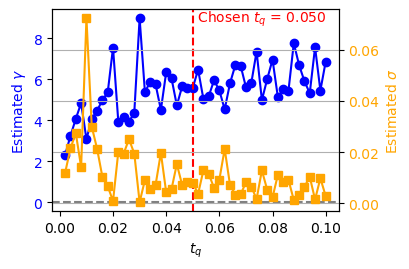

t_best=0.05,anomaly_ratio=0.02
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9230, P:0.8679, R:0.9526, F1:0.9083, FDR:0.9526, FAR:0.0967


In [8]:
set_seed(42)

alpha = beta = 1
conv_channels = [8]
latent_dim = 16
kernel_size = 3
activation = 'tanh'
use_batchnorm = False
lr = 0.0005
epochs = 100
lamb = 0.5
tau = 0.05
batch_size = 32

x_train, y_train, x_test, y_test, _, _ = tep_dataset(
    train_index=[0, 7, 8, 11, 13, 14],
    test_index=[2, 6, 18, 20],
)

# Conv1d expects tensors in (N, C, L) format.
tensor_x_train = torch.as_tensor(x_train.transpose((0, 2, 1)), dtype=torch.float32)
tensor_x_test = torch.as_tensor(x_test.transpose((0, 2, 1)), dtype=torch.float32)
tensor_y_test = torch.as_tensor(y_test, dtype=torch.float32)
train_loader = Data.DataLoader(
    dataset=tensor_x_train, batch_size=batch_size, shuffle=True, drop_last=True
)
test_loader = Data.DataLoader(
    dataset=Data.TensorDataset(tensor_x_test, tensor_y_test),
    batch_size=batch_size, shuffle=False, drop_last=False
)

# The adapter maps the six known classes to 0--5 and all unknowns to 6.
unknown_index = [6]

# Build the model.
model = FlexibleConv1dAutoencoder(
    in_channels=52,
    conv_channels=conv_channels,
    kernel_size=kernel_size,
    latent_dim=latent_dim,
    activation=activation,
    use_batchnorm=use_batchnorm
).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# Train the model.
model.train()
for epoch in range(epochs):
    for batch in train_loader:
        x = batch.to(device)
        out = model(x)
        loss = criterion(out, x) + lamb * contrastive_loss(
            x, out, tau, alpha, beta
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


# Compute reconstruction errors and evaluation metrics.
print("Testing")
model.eval()

train_errors = []
with torch.no_grad():
    for batch in train_loader:
        x = batch.to(device)
        out = model(x)
        error = torch.mean((x - out) ** 2, dim=[1, 2])
        train_errors.extend(error.cpu().numpy())

train_errors = np.asarray(train_errors)

all_errors = []
all_labels = []
with torch.no_grad():
    for batch in test_loader:
        x, y = batch[0].to(device), batch[1].to(device)
        out = model(x)
        error = torch.mean((x - out) ** 2, dim=[1, 2])
        all_errors.extend(error.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_labels = np.asarray(all_labels)
all_errors = np.asarray(all_errors)
leak_label = np.isin(all_labels, unknown_index).astype(int)

print(f'max_train_errors={train_errors.max():.4f}')
t_best = estimate_q_from_hill_plot_grimshaw(
    train_errors, SPOT(), (0.002, 0.1), 0.002
)
anomaly_ratio = math.ceil(t_best / 3 * 100) / 100
print(f't_best={t_best},anomaly_ratio={anomaly_ratio}')
spot = SPOT()
threshold, t, x0, t1, gamma, sigma = spot._pot(
    train_errors, anomaly_ratio, initial_thr_ratio=t_best
)

predictions = (all_errors >= threshold).astype(int)
p, r, f1, _ = precision_recall_fscore_support(
    leak_label, predictions, average='binary'
)
acc = accuracy_score(leak_label, predictions)
tn, fp, fn, tp = confusion_matrix(leak_label, predictions).ravel()
fdr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
far = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(
    f'Extreme Value threshold. '
    f'Acc:{acc:.4f}, '
    f'P:{p:.4f}, '
    f'R:{r:.4f}, '
    f'F1:{f1:.4f}, '
    f'FDR:{fdr:.4f}, '
    f'FAR:{far:.4f}'
)

In [9]:
# EVT sensitivity analysis on TEP.
for N_p in [2, 3, 4, 5, 6]:
    print('N_p', N_p)
    anomaly_ratio = math.ceil(t_best / N_p * 100) / 100
    print(f't_best={t_best},anomaly_ratio={anomaly_ratio}')

    spot = SPOT()
    threshold, t, x0, t1, gamma, sigma = spot._pot(
        train_errors, anomaly_ratio, initial_thr_ratio=t_best
    )

    predictions = (all_errors >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        leak_label, predictions, average='binary'
    )
    acc = accuracy_score(leak_label, predictions)
    print(f'Extreme Value threshold. Acc:{acc:.4f}, P:{p:.4f}, R:{r:.4f}, F1:{f1:.4f}')

N_p 2
t_best=0.05,anomaly_ratio=0.03
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9190, P:0.8581, R:0.9554, F1:0.9041
N_p 3
t_best=0.05,anomaly_ratio=0.02
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9230, P:0.8679, R:0.9526, F1:0.9083
N_p 4
t_best=0.05,anomaly_ratio=0.02
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9230, P:0.8679, R:0.9526, F1:0.9083
N_p 5
t_best=0.05,anomaly_ratio=0.01
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9000, P:1.0000, R:0.7500, F1:0.8571
N_p 6
t_best=0.05,anomaly_ratio=0.01
gamma=5.588,sigma=0.008018
Extreme Value threshold. Acc:0.9000, P:1.0000, R:0.7500, F1:0.8571
